# 위험등급 분류 기준 설계 — 다영

**목적**: 트랙A(실시간 운영 파이프라인)에서 LightGBM(조합3)의 예측확률을 1차 위험등급(Low/Medium/High/Critical 또는 5단계)으로 나눌 때, 그 경계를 무엇을 기준으로 정할지 데이터로 확인.

**진행 순서**
1. 확정된 LightGBM(조합3) 모델의 OOF 예측확률(3-Fold 통합, leak-safe) 재현
2. 확률 분포 확인 — 실제로 어디에 몰려있는지
3. Precision-Recall 곡선 + 임계값별 지표 — 등급 경계를 어디에 잡아야 의미가 있는지
4. (다음 단계) 4단계/5단계 후보안 여러 개를 이 데이터 위에 실제로 그어보고 비교

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import (
    average_precision_score, precision_recall_curve, precision_score, recall_score, f1_score,
)

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42


## 1. 데이터 로드 & 확정 스펙 불러오기

In [2]:
DATA_PATH = '../data/fraud_full_features.csv'

df = pd.read_csv(DATA_PATH)
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df = df.sort_values('trans_date_trans_time').reset_index(drop=True)

with open('../Modeling/final_lightgbm_combination3_config.json', encoding='utf-8') as f:
    FINAL_CONFIG = json.load(f)

COMBO3_FEATURES = FINAL_CONFIG['features']
HP = FINAL_CONFIG['hyperparameters']
OFFICIAL_THRESHOLD = FINAL_CONFIG['threshold']

print('데이터 크기 :', df.shape)
print('조합3 변수 :', COMBO3_FEATURES)
print('팀 공식 임계값(F1 최대) :', OFFICIAL_THRESHOLD)


데이터 크기 : (1296675, 31)
조합3 변수 : ['category', 'amt', 'trans_hour', 'age', 'recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'rolling_sum_amt_1h', 'amt_zscore_card', 'prior_normal_median_amt', 'count_30min', 'high_speed']
팀 공식 임계값(F1 최대) : 0.9289392017223173


## 2. OOF 예측확률 재현 (3-Fold, leak-safe)

다영/민정과 동일한 행 개수 6등분 확장형 3-Fold로 학습하고, 각 Fold의 Validation 예측확률을 전부 모음(OOF). 이렇게 하면 2019.10~2020.06 전체 기간을 아우르는 64만여 건짜리 대표성 있는 확률 분포를 얻을 수 있음.

In [3]:
boundaries = np.linspace(0, len(df), 7, dtype=int)
time_folds = []
for fold_number in range(1, 4):
    train_end = boundaries[fold_number + 2]
    val_start = train_end
    val_end = boundaries[fold_number + 3]
    time_folds.append({
        'fold': fold_number, 'train': df.iloc[0:train_end].copy(), 'val': df.iloc[val_start:val_end].copy(),
    })
    print(f"Fold {fold_number} | Train {train_end:,}건 | Val {val_end-val_start:,}건")


Fold 1 | Train 648,337건 | Val 216,113건
Fold 2 | Train 864,450건 | Val 216,112건
Fold 3 | Train 1,080,562건 | Val 216,113건


In [4]:
def prepare_lgbm_fold(train_fold, val_fold, features):
    X_train = train_fold[features].copy().reset_index(drop=True)
    X_val = val_fold[features].copy().reset_index(drop=True)
    y_train = train_fold['is_fraud'].astype(np.int8).reset_index(drop=True)
    y_val = val_fold['is_fraud'].astype(np.int8).reset_index(drop=True)

    train_cats = X_train['category'].astype('string').fillna('missing').unique().tolist()
    X_train['category'] = pd.Categorical(X_train['category'].astype('string').fillna('missing'), categories=train_cats)
    X_val['category'] = pd.Categorical(X_val['category'].astype('string').fillna('missing'), categories=train_cats)
    return X_train, X_val, y_train, y_val


oof_true, oof_proba = [], []
oof_time = []  # 각 예측이 언제 거래인지도 같이 보관 (나중에 시기별 분포 볼 때 필요할 수 있음)

for tf in time_folds:
    X_train, X_val, y_train, y_val = prepare_lgbm_fold(tf['train'], tf['val'], COMBO3_FEATURES)
    spw = (y_train == 0).sum() / (y_train == 1).sum()

    model = LGBMClassifier(
        objective='binary', n_estimators=3000, learning_rate=HP['learning_rate'],
        num_leaves=HP['num_leaves'], max_depth=HP['max_depth'], min_child_samples=HP['min_child_samples'],
        subsample=HP['subsample'], subsample_freq=HP['subsample_freq'], colsample_bytree=HP['colsample_bytree'],
        reg_alpha=HP['reg_alpha'], reg_lambda=HP['reg_lambda'], min_split_gain=HP['min_split_gain'],
        max_bin=HP['max_bin'], scale_pos_weight=spw, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
    )
    model.fit(
        X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='average_precision',
        categorical_feature=['category'],
        callbacks=[early_stopping(stopping_rounds=100, first_metric_only=True, verbose=False), log_evaluation(period=0)],
    )
    proba_val = model.predict_proba(X_val, num_iteration=model.best_iteration_)[:, 1]
    fold_pr_auc = average_precision_score(y_val, proba_val)
    print(f"Fold {tf['fold']} | best_iter={model.best_iteration_} | PR-AUC={fold_pr_auc:.6f}")

    oof_true.extend(y_val.to_numpy())
    oof_proba.extend(proba_val)
    oof_time.extend(tf['val']['trans_date_trans_time'].to_numpy())

oof_true = np.array(oof_true)
oof_proba = np.array(oof_proba)
oof_time = np.array(oof_time)

oof_pr_auc = average_precision_score(oof_true, oof_proba)
print(f"\nOOF 통합 PR-AUC = {oof_pr_auc:.6f} (참고: config.json 저장값 {FINAL_CONFIG['oof_results']['pr_auc']:.6f})")
print(f"OOF 전체 건수 = {len(oof_true):,}, 사기 건수 = {int(oof_true.sum()):,}")


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1 | best_iter=2214 | PR-AUC=0.974564


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2 | best_iter=1286 | PR-AUC=0.980634


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3 | best_iter=1756 | PR-AUC=0.977638

OOF 통합 PR-AUC = 0.976837 (참고: config.json 저장값 0.976837)
OOF 전체 건수 = 648,338, 사기 건수 = 3,679


## 3. 확률 분포 확인

정상거래와 사기거래, 예측확률이 실제로 어디에 몰려있는지 히스토그램으로 확인. 사기 비율이 0.58%뿐이라 일반 히스토그램은 정상거래(0 근처)에 다 몰려서 안 보일 수 있어 y축을 로그스케일로도 같이 봄.

C:\Users\user\AppData\Local\Temp\ipykernel_3656\3308861322.py:13: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3656\3308861322.py:13: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3656\3308861322.py:13: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3656\3308861322.py:13: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3656\3308861322.py:13: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3656\3308861322.py:13: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) 

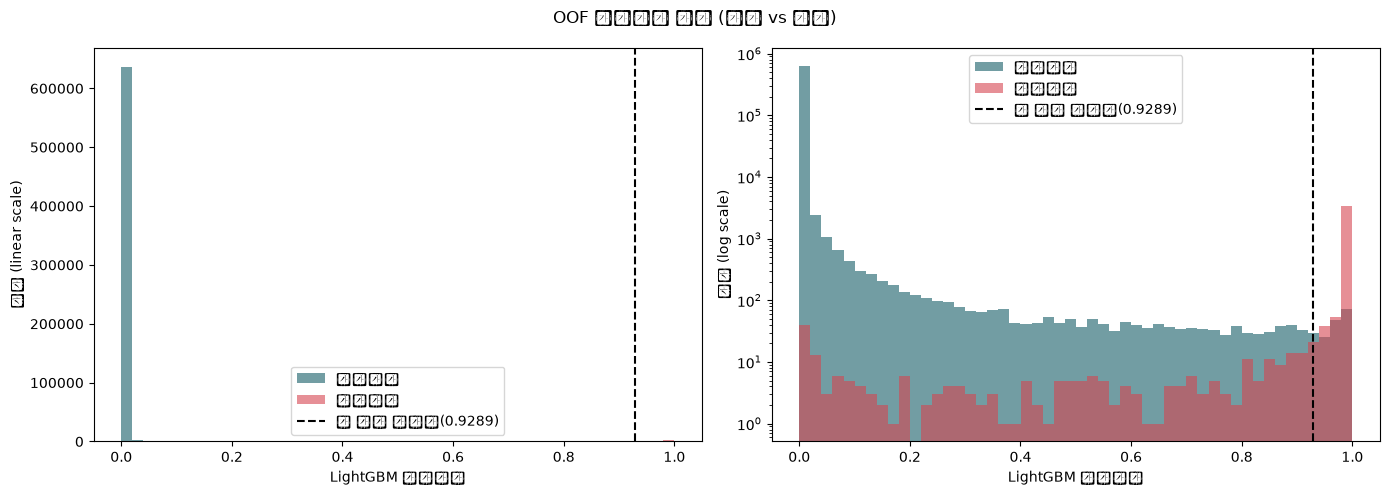

=== 정상거래 예측확률 백분위수 ===
50%: 0.000003
90%: 0.000234
95%: 0.001039
99%: 0.027493
99.5%: 0.091236
99.9%: 0.645038

=== 사기거래 예측확률 백분위수 ===
1%: 0.016665
5%: 0.811869
10%: 0.981728
25%: 0.999161
50%: 0.999936


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, yscale in zip(axes, ['linear', 'log']):
    ax.hist(oof_proba[oof_true == 0], bins=50, alpha=0.6, label='정상거래', color='#145C66')
    ax.hist(oof_proba[oof_true == 1], bins=50, alpha=0.6, label='사기거래', color='#D64550')
    ax.axvline(OFFICIAL_THRESHOLD, color='black', linestyle='--', linewidth=1.5, label=f'팀 공식 임계값({OFFICIAL_THRESHOLD:.4f})')
    ax.set_yscale(yscale)
    ax.set_xlabel('LightGBM 예측확률')
    ax.set_ylabel(f'건수 ({yscale} scale)')
    ax.legend()

plt.suptitle('OOF 예측확률 분포 (정상 vs 사기)')
plt.tight_layout()
plt.show()

print('=== 정상거래 예측확률 백분위수 ===')
for p in [50, 90, 95, 99, 99.5, 99.9]:
    print(f'{p}%: {np.percentile(oof_proba[oof_true==0], p):.6f}')

print('\n=== 사기거래 예측확률 백분위수 ===')
for p in [1, 5, 10, 25, 50]:
    print(f'{p}%: {np.percentile(oof_proba[oof_true==1], p):.6f}')


## 4. Precision-Recall 곡선 + 임계값별 지표표

임계값을 촘촘히 훑으면서 Precision/Recall/F1/건수가 어떻게 변하는지 확인 — 등급 경계 후보를 잡을 때 참고.

C:\Users\user\AppData\Local\Temp\ipykernel_3656\3029905310.py:12: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3656\3029905310.py:12: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3656\3029905310.py:12: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3656\3029905310.py:12: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3656\3029905310.py:12: UserWarning: Glyph 54016 (\N{HANGUL SYLLABLE TIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_3656\3029905310.py:12: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s)

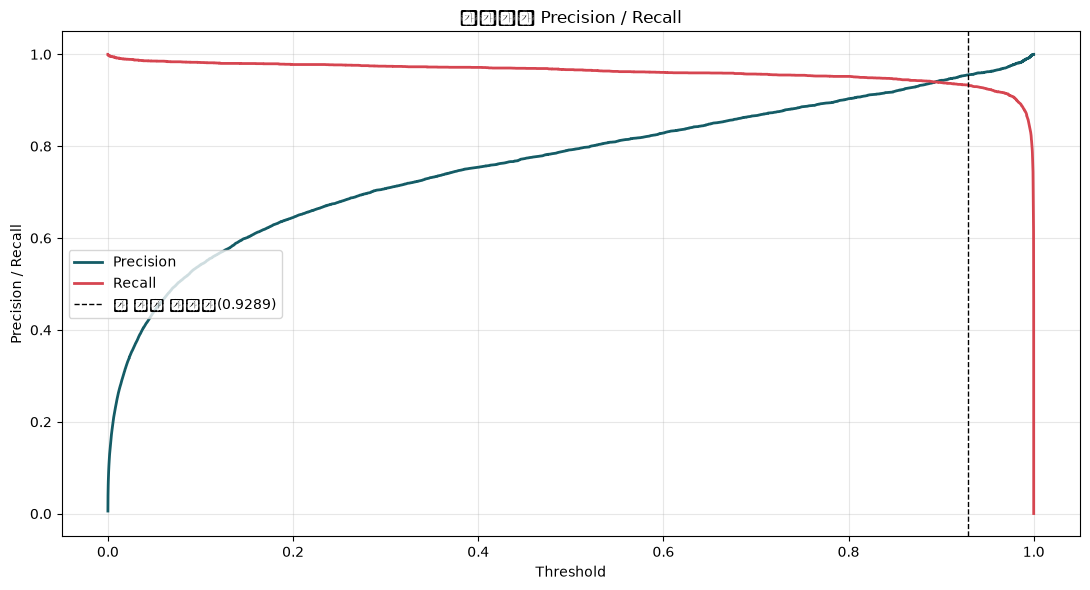

In [6]:
precisions, recalls, thresholds = precision_recall_curve(oof_true, oof_proba)

fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.plot(thresholds, precisions[:-1], label='Precision', color='#145C66', linewidth=2)
ax1.plot(thresholds, recalls[:-1], label='Recall', color='#D64550', linewidth=2)
ax1.axvline(OFFICIAL_THRESHOLD, color='black', linestyle='--', linewidth=1, label=f'팀 공식 임계값({OFFICIAL_THRESHOLD:.4f})')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Precision / Recall')
ax1.legend(loc='center left')
ax1.set_title('임계값별 Precision / Recall')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:
# 임계값 후보를 촘촘히 훑으면서 각 지점에서의 실질적 의미(Precision/Recall/건수) 표로 정리
threshold_candidates = np.concatenate([
    np.arange(0.0, 0.1, 0.01),
    np.arange(0.1, 0.9, 0.05),
    np.arange(0.9, 1.0, 0.01),
])

rows = []
for t in threshold_candidates:
    pred = (oof_proba >= t).astype(int)
    n_flagged = pred.sum()
    p = precision_score(oof_true, pred, zero_division=0)
    r = recall_score(oof_true, pred, zero_division=0)
    f1 = f1_score(oof_true, pred, zero_division=0)
    rows.append({
        'threshold': round(float(t), 3), '해당건수': n_flagged,
        'precision': round(p, 4), 'recall': round(r, 4), 'f1': round(f1, 4),
    })

threshold_table = pd.DataFrame(rows)
print(threshold_table.to_string(index=False))


 threshold   해당건수  precision  recall     f1
      0.00 648338     0.0057  1.0000 0.0113
      0.01  14554     0.2507  0.9918 0.4003
      0.02  11262     0.3232  0.9894 0.4872
      0.03   9792     0.3710  0.9875 0.5394
      0.04   8859     0.4094  0.9859 0.5786
      0.05   8227     0.4406  0.9853 0.6089
      0.06   7773     0.4662  0.9851 0.6329
      0.07   7369     0.4911  0.9837 0.6551
      0.08   7106     0.5091  0.9834 0.6709
      0.09   6867     0.5264  0.9826 0.6856
      0.10   6670     0.5417  0.9821 0.6982
      0.15   5999     0.6009  0.9799 0.7450
      0.20   5579     0.6447  0.9777 0.7771
      0.25   5296     0.6786  0.9769 0.8009
      0.30   5063     0.7079  0.9742 0.8199
      0.35   4886     0.7321  0.9723 0.8353
      0.40   4739     0.7542  0.9715 0.8491
      0.45   4615     0.7729  0.9696 0.8601
      0.50   4490     0.7920  0.9666 0.8706
      0.55   4369     0.8107  0.9628 0.8802
      0.60   4264     0.8288  0.9606 0.8898
      0.65   4161     0.8481  0.

## 5. 4단계 / 5단계 위험등급 컬럼 추가

확률 분포·Precision-Recall 표에서 실제로 의미가 갈리는 지점(0.01 / 0.5 / 0.9289)을 경계로 사용.

- **4단계**: Low(0~0.01) / Medium(0.01~0.5) / High(0.5~0.9289) / Critical(0.9289~1)
- **5단계**: Low를 한 번 더 쪼갬 — 안정형(0~0.001) / 안정추구형(0.001~0.01) / 위험중립형(0.01~0.5) / 적극투자형(0.5~0.9289) / 공격투자형(0.9289~1)

⚠️ 아직 확정안 아님 — 데이터로 뽑아보고 등급별 건수·사기율이 실제로 말이 되는지 다음 셀에서 바로 확인.

In [8]:
oof_df = pd.DataFrame({'y_true': oof_true, 'y_prob': oof_proba})

# ----- 4단계 -----
TIER4_BOUNDARIES = [0.0, 0.01, 0.50, OFFICIAL_THRESHOLD, 1.0 + 1e-9]
TIER4_LABELS = ['Low', 'Medium', 'High', 'Critical']

oof_df['tier_4'] = pd.cut(
    oof_df['y_prob'], bins=TIER4_BOUNDARIES, labels=TIER4_LABELS,
    right=False, include_lowest=True,
)

# ----- 5단계 -----
TIER5_BOUNDARIES = [0.0, 0.001, 0.01, 0.50, OFFICIAL_THRESHOLD, 1.0 + 1e-9]
TIER5_LABELS = ['안정형(매우낮음)', '안정추구형(낮음)', '위험중립형(중간)', '적극투자형(높음)', '공격투자형(매우높음)']

oof_df['tier_5'] = pd.cut(
    oof_df['y_prob'], bins=TIER5_BOUNDARIES, labels=TIER5_LABELS,
    right=False, include_lowest=True,
)

print('=== 컬럼 추가 완료 ===')
print(oof_df.head())
print('\n결측 확인 (등급이 안 매겨진 행이 있으면 안 됨):')
print(oof_df[['tier_4', 'tier_5']].isna().sum())


=== 컬럼 추가 완료 ===
   y_true        y_prob tier_4     tier_5
0       0  2.246974e-05    Low  안정형(매우낮음)
1       0  6.890354e-09    Low  안정형(매우낮음)
2       0  9.174480e-07    Low  안정형(매우낮음)
3       0  6.838027e-07    Low  안정형(매우낮음)
4       0  7.502916e-11    Low  안정형(매우낮음)

결측 확인 (등급이 안 매겨진 행이 있으면 안 됨):
tier_4    0
tier_5    0
dtype: int64


## 6. 등급별 건수 · 사기율 확인 (4단계 / 5단계)

In [9]:
def tier_summary(df, tier_col, order):
    g = df.groupby(tier_col, observed=True).agg(
        건수=('y_true', 'size'), 사기건수=('y_true', 'sum'), 사기율=('y_true', 'mean'),
    ).reindex(order)
    g['비율(%)'] = (g['건수'] / len(df) * 100).round(2)
    g['사기율(%)'] = (g['사기율'] * 100).round(4)
    overall_rate = df['y_true'].mean() * 100
    g['전체평균대비_배수'] = (g['사기율(%)'] / overall_rate).round(1)
    return g[['건수', '비율(%)', '사기건수', '사기율(%)', '전체평균대비_배수']]

print('=== 4단계 등급별 요약 ===')
print(tier_summary(oof_df, 'tier_4', TIER4_LABELS))

print('\n=== 5단계 등급별 요약 ===')
print(tier_summary(oof_df, 'tier_5', TIER5_LABELS))

print(f"\n전체 평균 사기율: {oof_df['y_true'].mean()*100:.4f}%")


=== 4단계 등급별 요약 ===
              건수  비율(%)  사기건수   사기율(%)  전체평균대비_배수
tier_4                                           
Low       633784  97.76    30   0.0047        0.0
Medium     10064   1.55    93   0.9241        1.6
High         895   0.14   122  13.6313       24.0
Critical    3595   0.55  3434  95.5216      168.3

=== 5단계 등급별 요약 ===
                 건수  비율(%)  사기건수   사기율(%)  전체평균대비_배수
tier_5                                              
안정형(매우낮음)    611858  94.37     9   0.0015        0.0
안정추구형(낮음)     21926   3.38    21   0.0958        0.2
위험중립형(중간)     10064   1.55    93   0.9241        1.6
적극투자형(높음)       895   0.14   122  13.6313       24.0
공격투자형(매우높음)    3595   0.55  3434  95.5216      168.3

전체 평균 사기율: 0.5675%


## 7. 라우팅 실험 준비 — 등급별 행동변수 붙이기

OOF 예측(`oof_df`)은 확률·정답만 갖고 있어서, 군집분석에 썼던 7개 행동변수를 원본 `df`에서 시간순으로 그대로 붙임 (OOF는 3-Fold Validation을 순서대로 이어붙인 거라, `df`를 앞의 1/6~6/6 구간 중 뒤 3개 Fold Validation과 동일한 순서로 이어붙이면 행 순서가 정확히 일치).

In [10]:
BEHAVIOR_FEATURES = [
    'amt', 'trans_hour', 'recent_24h_high_amt_count', 'amt_to_prior_median_ratio',
    'rolling_sum_amt_1h', 'amt_zscore_card', 'count_30min',
]

# OOF와 동일한 순서로 원본 행동변수 이어붙이기 (Fold1 val + Fold2 val + Fold3 val)
oof_features_list = []
for tf in time_folds:
    oof_features_list.append(tf['val'][BEHAVIOR_FEATURES].reset_index(drop=True))
oof_features = pd.concat(oof_features_list, axis=0).reset_index(drop=True)

assert len(oof_features) == len(oof_df), '행 개수가 안 맞음 - 순서 확인 필요'

oof_df = pd.concat([oof_df.reset_index(drop=True), oof_features], axis=1)
print('결합 완료:', oof_df.shape)
print(oof_df.head())


결합 완료: (648338, 11)
   y_true        y_prob tier_4     tier_5     amt  trans_hour  recent_24h_high_amt_count  amt_to_prior_median_ratio  rolling_sum_amt_1h  amt_zscore_card  count_30min
0       0  2.246974e-05    Low  안정형(매우낮음)   50.75           7                          0                   1.375525               50.75        -0.070316            1
1       0  6.890354e-09    Low  안정형(매우낮음)    1.14           7                          0                   0.024532                1.14        -0.687845            1
2       0  9.174480e-07    Low  안정형(매우낮음)  271.99           7                          0                   7.066511              271.99         0.400806            0
3       0  6.838027e-07    Low  안정형(매우낮음)   91.37           7                          0                   1.860138               91.37         0.223301            1
4       0  7.502916e-11    Low  안정형(매우낮음)    3.04           7                          0                   0.081002                3.04        -0.4107

## 8. ❌(채택 안 함) DBSCAN 안전망 체크 실험 — 어느 '안전' 등급에서 효과 있나

각 후보 하위집합에 DBSCAN을 돌려서, **Noise로 찍힌 거래의 사기율이 그 등급 전체 평균보다 얼마나 높은지(Lift)** 측정. Lift가 크면 "이 등급에 DBSCAN 돌리는 게 숨은 사기를 실제로 더 잘 잡아낸다"는 뜻.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

LOG_POSITIVE_COLS = ['amt', 'amt_to_prior_median_ratio', 'rolling_sum_amt_1h', 'recent_24h_high_amt_count']
LOG_SIGNED_COLS = ['amt_zscore_card']
EPS_FINAL = 0.5
MIN_SAMPLES_FINAL = 10
DBSCAN_SAMPLE_SIZE = 150_000


def scale_features(sub_df, feature_cols=BEHAVIOR_FEATURES):
    X = sub_df[feature_cols].copy()
    fill_values = X.median(numeric_only=True).to_dict()
    X = X.fillna(fill_values)
    for c in LOG_POSITIVE_COLS:
        X[c] = np.log1p(X[c].clip(lower=0))
    for c in LOG_SIGNED_COLS:
        X[c] = np.sign(X[c]) * np.log1p(X[c].abs())
    return StandardScaler().fit_transform(X)


def dbscan_noise_lift(sub_df, label, eps=EPS_FINAL, min_samples=MIN_SAMPLES_FINAL, sample_size=DBSCAN_SAMPLE_SIZE):
    X_scaled = scale_features(sub_df)
    n = len(X_scaled)

    if n > sample_size:
        rng = np.random.RandomState(RANDOM_STATE)
        sample_idx = rng.choice(n, size=sample_size, replace=False)
    else:
        sample_idx = np.arange(n)
    X_sample = X_scaled[sample_idx]

    db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    sample_labels = db.fit_predict(X_sample)
    core_samples = X_sample[db.core_sample_indices_]
    core_labels = sample_labels[db.core_sample_indices_]

    if len(core_samples) == 0:
        is_noise = np.ones(n, dtype=bool)
    else:
        nn = NearestNeighbors(n_neighbors=1)
        nn.fit(core_samples)
        dist, idx = nn.kneighbors(X_scaled)
        is_noise = dist[:, 0] > eps

    y = sub_df['y_true'].to_numpy()
    baseline_rate = y.mean()
    noise_rate = y[is_noise].mean() if is_noise.sum() > 0 else 0.0
    normal_rate = y[~is_noise].mean() if (~is_noise).sum() > 0 else 0.0

    result = {
        '대상': label, '전체건수': n, '전체사기율(%)': round(baseline_rate * 100, 4),
        'Noise건수': int(is_noise.sum()), 'Noise비율(%)': round(is_noise.mean() * 100, 2),
        'Noise내사기율(%)': round(noise_rate * 100, 4), '정상판정내사기율(%)': round(normal_rate * 100, 6),
        'Lift(Noise/전체)': round(noise_rate / baseline_rate, 1) if baseline_rate > 0 else float('nan'),
        'Noise가잡은사기건수': int(y[is_noise].sum()), '해당집합전체사기건수': int(y.sum()),
    }
    print(result)
    return result


In [12]:
dbscan_experiment_rows = []

dbscan_experiment_rows.append(dbscan_noise_lift(oof_df[oof_df['tier_4'] == 'Low'], 'Low(4단계 전체)'))
dbscan_experiment_rows.append(dbscan_noise_lift(oof_df[oof_df['tier_5'] == '안정형(매우낮음)'], '안정형(5단계)'))
dbscan_experiment_rows.append(dbscan_noise_lift(oof_df[oof_df['tier_5'] == '안정추구형(낮음)'], '안정추구형(5단계)'))
dbscan_experiment_rows.append(dbscan_noise_lift(oof_df[oof_df['tier_4'] == 'Medium'], 'Medium(참고용)'))

print('\n=== DBSCAN 안전망 실험 요약 ===')
print(pd.DataFrame(dbscan_experiment_rows).to_string(index=False))


{'대상': 'Low(4단계 전체)', '전체건수': 633784, '전체사기율(%)': np.float64(0.0047), 'Noise건수': 9391, 'Noise비율(%)': np.float64(1.48), 'Noise내사기율(%)': np.float64(0.0106), '정상판정내사기율(%)': np.float64(0.004645), 'Lift(Noise/전체)': np.float64(2.2), 'Noise가잡은사기건수': 1, '해당집합전체사기건수': 30}
{'대상': '안정형(5단계)', '전체건수': 611858, '전체사기율(%)': np.float64(0.0015), 'Noise건수': 8276, 'Noise비율(%)': np.float64(1.35), 'Noise내사기율(%)': np.float64(0.0), '정상판정내사기율(%)': np.float64(0.001491), 'Lift(Noise/전체)': np.float64(0.0), 'Noise가잡은사기건수': 0, '해당집합전체사기건수': 9}
{'대상': '안정추구형(5단계)', '전체건수': 21926, '전체사기율(%)': np.float64(0.0958), 'Noise건수': 1080, 'Noise비율(%)': np.float64(4.93), 'Noise내사기율(%)': np.float64(0.1852), '정상판정내사기율(%)': np.float64(0.091145), 'Lift(Noise/전체)': np.float64(1.9), 'Noise가잡은사기건수': 2, '해당집합전체사기건수': 21}
{'대상': 'Medium(참고용)', '전체건수': 10064, '전체사기율(%)': np.float64(0.9241), 'Noise건수': 683, 'Noise비율(%)': np.float64(6.79), 'Noise내사기율(%)': np.float64(1.3177), '정상판정내사기율(%)': np.float64(0.895427), 'Lift(Noise/전체)': np.float6

## 9. K-means 유형분석 실험 — 어느 '위험' 등급에서 효과 있나

각 후보 하위집합에 K-means(K=2~4)를 돌려서, **군집별 사기율이 실제로 얼마나 벌어지는지(최대/최소 비율)** 확인. 차이가 크면 "이 등급을 세분화하는 게 대응을 다르게 할 실익이 있다"는 뜻.

In [13]:
from sklearn.cluster import KMeans


def kmeans_subtype_spread(sub_df, label, k_candidates=(2, 3, 4)):
    X_scaled = scale_features(sub_df)
    y = sub_df['y_true'].to_numpy()
    baseline_rate = y.mean()

    rows = []
    for k in k_candidates:
        if len(sub_df) < k * 5:
            continue
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X_scaled)

        cluster_rates = [y[labels == c].mean() if (labels == c).sum() > 0 else 0.0 for c in range(k)]
        cluster_sizes = [int((labels == c).sum()) for c in range(k)]

        spread = (max(cluster_rates) / min(cluster_rates)) if min(cluster_rates) > 0 else float('inf')
        rows.append({
            '대상': label, 'K': k, '전체사기율(%)': round(baseline_rate * 100, 4),
            '군집별사기율(%)': [round(r * 100, 4) for r in cluster_rates],
            '군집별건수': cluster_sizes, '최대/최소_spread': round(spread, 1) if spread != float('inf') else spread,
        })
    for r in rows:
        print(r)
    return rows


In [14]:
kmeans_experiment_rows = []
kmeans_experiment_rows += kmeans_subtype_spread(oof_df[oof_df['tier_4'] == 'Medium'], 'Medium')
kmeans_experiment_rows += kmeans_subtype_spread(oof_df[oof_df['tier_4'] == 'High'], 'High')
kmeans_experiment_rows += kmeans_subtype_spread(oof_df[oof_df['tier_4'] == 'Critical'], 'Critical')
kmeans_experiment_rows += kmeans_subtype_spread(
    oof_df[oof_df['tier_4'].isin(['Medium', 'High', 'Critical'])], 'Medium+High+Critical(통합)')

print('\n=== K-means 유형분석 실험 요약 ===')
print(pd.DataFrame(kmeans_experiment_rows).to_string(index=False))


{'대상': 'Medium', 'K': 2, '전체사기율(%)': np.float64(0.9241), '군집별사기율(%)': [np.float64(0.9349), np.float64(0.9204)], '군집별건수': [2567, 7497], '최대/최소_spread': np.float64(1.0)}
{'대상': 'Medium', 'K': 3, '전체사기율(%)': np.float64(0.9241), '군집별사기율(%)': [np.float64(1.3456), np.float64(0.7955), np.float64(0.9603)], '군집별건수': [1635, 6034, 2395], '최대/최소_spread': np.float64(1.7)}
{'대상': 'Medium', 'K': 4, '전체사기율(%)': np.float64(0.9241), '군집별사기율(%)': [np.float64(0.8687), np.float64(1.1214), np.float64(0.5283), np.float64(1.3836)], '군집별건수': [5065, 1516, 1893, 1590], '최대/최소_spread': np.float64(2.6)}
{'대상': 'High', 'K': 2, '전체사기율(%)': np.float64(13.6313), '군집별사기율(%)': [np.float64(13.6247), np.float64(13.6364)], '군집별건수': [389, 506], '최대/최소_spread': np.float64(1.0)}
{'대상': 'High', 'K': 3, '전체사기율(%)': np.float64(13.6313), '군집별사기율(%)': [np.float64(13.7203), np.float64(7.1161), np.float64(20.4819)], '군집별건수': [379, 267, 249], '최대/최소_spread': np.float64(2.9)}
{'대상': 'High', 'K': 4, '전체사기율(%)': np.float64(13.6313), '군집

## 10. ❌(채택 안 함) DBSCAN eps/min_samples 그리드 실험 — '안전' 등급 안에서 더 민감하게 잡을 수 있나

기존 eps=0.5는 전체 데이터 기준으로 튜닝한 값. Low/안정형/안정추구형처럼 이미 '위험도가 낮다'고 걸러진 부분집합은 분포가 훨씬 촘촘할 수 있어서, 더 작은 eps가 오히려 숨은 사기를 잘 잡아낼 수도 있음 — 그리드로 확인.

In [15]:
def dbscan_grid(sub_df, label, eps_list, min_samples_list, sample_size=DBSCAN_SAMPLE_SIZE):
    X_scaled = scale_features(sub_df)
    y = sub_df['y_true'].to_numpy()
    n = len(X_scaled)
    baseline_rate = y.mean()
    total_fraud = int(y.sum())

    if n > sample_size:
        rng = np.random.RandomState(RANDOM_STATE)
        sample_idx = rng.choice(n, size=sample_size, replace=False)
    else:
        sample_idx = np.arange(n)
    X_sample = X_scaled[sample_idx]

    rows = []
    for eps in eps_list:
        for min_samples in min_samples_list:
            db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
            sample_labels = db.fit_predict(X_sample)
            core_samples = X_sample[db.core_sample_indices_]
            core_labels = sample_labels[db.core_sample_indices_]

            if len(core_samples) == 0:
                is_noise = np.ones(n, dtype=bool)
            else:
                nn = NearestNeighbors(n_neighbors=1)
                nn.fit(core_samples)
                dist, idx = nn.kneighbors(X_scaled)
                is_noise = dist[:, 0] > eps

            noise_rate = y[is_noise].mean() if is_noise.sum() > 0 else 0.0
            caught = int(y[is_noise].sum())
            lift = round(noise_rate / baseline_rate, 1) if baseline_rate > 0 else float('nan')

            rows.append({
                '대상': label, 'eps': eps, 'min_samples': min_samples,
                'Noise비율(%)': round(is_noise.mean() * 100, 2), 'Lift': lift,
                '잡은사기': caught, '전체사기': total_fraud,
                '포착율(%)': round(caught / total_fraud * 100, 1) if total_fraud > 0 else float('nan'),
            })
    return rows


In [16]:
EPS_GRID = [0.1, 0.15, 0.2, 0.3, 0.4]
MIN_SAMPLES_GRID = [5, 10, 20]

dbscan_grid_rows = []
dbscan_grid_rows += dbscan_grid(oof_df[oof_df['tier_5'] == '안정형(매우낮음)'], '안정형', EPS_GRID, MIN_SAMPLES_GRID)
dbscan_grid_rows += dbscan_grid(oof_df[oof_df['tier_5'] == '안정추구형(낮음)'], '안정추구형', EPS_GRID, MIN_SAMPLES_GRID)
dbscan_grid_rows += dbscan_grid(oof_df[oof_df['tier_4'] == 'Low'], 'Low(4단계)', EPS_GRID, MIN_SAMPLES_GRID)

dbscan_grid_df = pd.DataFrame(dbscan_grid_rows)
print('=== DBSCAN eps/min_samples 그리드 결과 (포착율 내림차순) ===')
print(dbscan_grid_df.sort_values('포착율(%)', ascending=False).to_string(index=False))


=== DBSCAN eps/min_samples 그리드 결과 (포착율 내림차순) ===
      대상  eps  min_samples  Noise비율(%)  Lift  잡은사기  전체사기  포착율(%)
     안정형 0.10           20       62.92   1.2     7     9    77.8
Low(4단계) 0.10           20       60.98   1.1    21    30    70.0
     안정형 0.10           10       44.71   1.2     5     9    55.6
Low(4단계) 0.10           10       43.68   1.2    16    30    53.3
   안정추구형 0.10           20       60.45   0.9    11    21    52.4
   안정추구형 0.10           10       50.49   0.8     9    21    42.9
   안정추구형 0.15           20       47.35   0.9     9    21    42.9
   안정추구형 0.20           20       34.17   1.1     8    21    38.1
   안정추구형 0.15           10       39.56   1.0     8    21    38.1
   안정추구형 0.10            5       41.21   0.9     8    21    38.1
Low(4단계) 0.15           20       36.38   1.0    11    30    36.7
Low(4단계) 0.10            5       33.67   1.1    11    30    36.7
     안정형 0.10            5       33.92   1.0     3     9    33.3
   안정추구형 0.20           10       26.34   

## 11. K-means(Medium+High+Critical 통합) 군집별 프로파일링 — 실제로 무슨 유형인가

K=4로 통합 군집화한 뒤, 각 군집의 실제 행동변수 평균을 찍어서 '소액테스트형/몰아쓰기형/한탕고액형' 같은 이름을 붙여봄. 등급(Medium/High/Critical)과 유형(K-means 군집)이 서로 독립적인 정보인지도 같이 확인.

In [17]:
mhc_df = oof_df[oof_df['tier_4'].isin(['Medium', 'High', 'Critical'])].copy()
X_mhc_scaled = scale_features(mhc_df)

km_mhc = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
mhc_df['cluster'] = km_mhc.fit_predict(X_mhc_scaled)

print('=== 군집별 평균 행동특성 (원 단위 그대로) ===')
print(mhc_df.groupby('cluster')[BEHAVIOR_FEATURES].mean().round(2))

print('\n=== 군집별 크기 & 사기율 ===')
cluster_summary = mhc_df.groupby('cluster').agg(
    건수=('y_true', 'size'), 사기건수=('y_true', 'sum'), 사기율=('y_true', 'mean'),
)
cluster_summary['사기율(%)'] = (cluster_summary['사기율'] * 100).round(2)
print(cluster_summary[['건수', '사기건수', '사기율(%)']])

print('\n=== 등급(tier_4) x 유형(cluster) 교차표 — 서로 독립적인 정보인지 확인 ===')
print(pd.crosstab(mhc_df['tier_4'], mhc_df['cluster']))


=== 군집별 평균 행동특성 (원 단위 그대로) ===
            amt  trans_hour  recent_24h_high_amt_count  amt_to_prior_median_ratio  rolling_sum_amt_1h  amt_zscore_card  count_30min
cluster                                                                                                                            
0         21.20       20.04                       0.32                       0.50               53.31            -0.42         1.09
1        969.73       16.14                       0.98                      24.56             1263.89             7.22         0.30
2        276.50       14.64                       0.79                       6.22              467.53             1.47         1.20
3         14.55        4.02                       0.48                       0.34               55.20            -0.57         0.66

=== 군집별 크기 & 사기율 ===
           건수  사기건수  사기율(%)
cluster                    
0        6035   321    5.32
1        3373  1670   49.51
2        3721  1305   35.07
3        1425  

## 12. 최종 결론 — 트랙A 1차 위험등급 분류 설계 (확정)

### 최종 결정
- **등급 개수: 4단계** (Low / Medium / High / Critical)
- **비지도학습 라우팅: K-means만 채택, DBSCAN은 제외**
- Medium·High·Critical을 **통합해서 K=4로 K-means** 적용 (개별 등급마다 따로 하지 않음)

### 왜 4단계인가 (5단계 아닌 이유)
5단계(Low를 안정형/안정추구형으로 분리)를 검토했던 이유는 "DBSCAN을 Low 전체에 적용할지, 일부에만 적용할지"를 정하기 위해서였음. DBSCAN 자체를 최종적으로 제외하기로 하면서, 그 분리의 실질적 이유가 사라짐 — 안정형/안정추구형 둘 다 결국 '그대로 승인'으로 동일하게 처리되므로 나눌 실익이 없음. 따라서 원래 확률분포·PR곡선에서 실질적 경계가 뚜렷했던 4단계로 확정.

### 왜 DBSCAN을 뺐는가
- eps/min_samples 45개 조합을 그리드로 다 시도했지만(안정형·안정추구형·Low 전체 대상), **노이즈로 찍힌 거래의 사기 농도(Lift)가 최대 3.6배 수준에 그치고, 대부분 1~2배권으로 사실상 무의미**
- Lift를 조금이라도 올리려면 노이즈 비율이 30~60%까지 치솟아서, '안전 등급의 절반을 다시 의심'하는 꼴이 되어 애초에 등급을 나눈 목적(자동 승인 가능한 대량 구간 확보)과 상충
- 안정형(94.4%, 사기 9건)은 기본 파라미터(eps=0.5)에서 노이즈가 사기를 **0건** 잡아냄 — 가장 극단적인 반례

### 왜 K-means는 '통합'으로 채택했는가
- Medium/High/Critical 개별로 K-means: 사기율 spread 1.0~2.9배 (약함)
- **Medium+High+Critical 통합 K-means(K=4): spread 9.3배** — 압도적으로 우수
- 등급(LightGBM)과 유형(K-means)이 서로 독립적인 축임을 교차표로 확인 (어느 등급에나 4개 유형이 다 섞여 있음) → 통합해도 등급별 세분화 능력이 사라지지 않음, 오히려 표본이 커져서(4,490건) 유형 구분이 더 안정적임
- 4개 유형에 실제 해석 가능한 이름을 붙일 수 있었음(아래 표)

In [18]:
# 최종 확정 경계값 재확인 (4단계)
print('=== 최종 확정: 트랙A 1차 위험등급 (4단계) ===')
final_tier4 = pd.DataFrame([
    {'등급': 'Low', '확률구간': '0 ~ 0.01', '처리': '그대로 승인 (비지도학습 없음)'},
    {'등급': 'Medium', '확률구간': '0.01 ~ 0.50', '처리': 'K-means(통합) 유형분류 → 대응'},
    {'등급': 'High', '확률구간': '0.50 ~ %.4f' % OFFICIAL_THRESHOLD, '처리': 'K-means(통합) 유형분류 → 대응'},
    {'등급': 'Critical', '확률구간': '%.4f ~ 1.0' % OFFICIAL_THRESHOLD, '처리': 'K-means(통합) 유형분류 → 대응'},
])
print(final_tier4.to_string(index=False))

print('\n=== 최종 확정: K-means 유형 (Medium+High+Critical 통합, K=4) ===')
final_kmeans_types = pd.DataFrame([
    {'군집': 1, '제안 유형명': '한탕고액형', '특징': '고액(970원) + zscore 극단적(+7.22) + 저빈도', '사기율': '49.51%'},
    {'군집': 2, '제안 유형명': '몰아쓰기형', '특징': '중고액(277원) + 낮시간 + 약간 고빈도', '사기율': '35.07%'},
    {'군집': 3, '제안 유형명': '새벽 소액테스트형', '특징': '초소액(15원) + 새벽4시', '사기율': '24.77%'},
    {'군집': 0, '제안 유형명': '소액 저녁형', '특징': '소액(21원) + 저녁8시, 상대적으로 안전', '사기율': '5.32%'},
])
print(final_kmeans_types.to_string(index=False))


=== 최종 확정: 트랙A 1차 위험등급 (4단계) ===
      등급          확률구간                    처리
     Low      0 ~ 0.01     그대로 승인 (비지도학습 없음)
  Medium   0.01 ~ 0.50 K-means(통합) 유형분류 → 대응
    High 0.50 ~ 0.9289 K-means(통합) 유형분류 → 대응
Critical  0.9289 ~ 1.0 K-means(통합) 유형분류 → 대응

=== 최종 확정: K-means 유형 (Medium+High+Critical 통합, K=4) ===
 군집    제안 유형명                                 특징    사기율
  1     한탕고액형 고액(970원) + zscore 극단적(+7.22) + 저빈도 49.51%
  2     몰아쓰기형           중고액(277원) + 낮시간 + 약간 고빈도 35.07%
  3 새벽 소액테스트형                    초소액(15원) + 새벽4시 24.77%
  0    소액 저녁형           소액(21원) + 저녁8시, 상대적으로 안전  5.32%


## 13. (추가 검토) High~Critical 사기율 격차 완화 — 경계 하나 더 추가

**문제제기**: 확정된 4단계에서 High(0.50~OFFICIAL_THRESHOLD, 사기율 ≈13%)와 Critical(OFFICIAL_THRESHOLD~1.0, 사기율 ≈95%) 사이 사기율 격차가 너무 커서, 두 등급에 서로 다른 대응 방안을 설계하기가 어려움.

**방법**: Critical 경계(OFFICIAL_THRESHOLD = 팀 공식 F1 최적 임계값)는 운영상 의미가 있는 지점이므로 그대로 유지하고, 그 아래 High 구간(0.50~OFFICIAL_THRESHOLD) 안에 경계를 하나 더 그어서 3덩어리로 쪼갤 수 있는지 확인.

- 상단을 OFFICIAL_THRESHOLD로 고정
- 하단 경계 `t`를 0.50부터 OFFICIAL_THRESHOLD까지 촘촘히 훑으면서, 구간 `[t, OFFICIAL_THRESHOLD)`의 사기율이 어떻게 변하는지 관찰 (확률이 높을수록 사기율도 대체로 단조증가하므로, t를 OFFICIAL_THRESHOLD 쪽으로 좁힐수록 그 구간 사기율은 올라감)
- 목표 사기율(예: 50%)에 가장 가까운 `t`를 자동 탐색 → 그 지점을 새 경계로 채택하면 `Low / Medium / High(하) / High(상) / Critical` 5단계가 됨

⚠️ 어디까지나 탐색용 — 결과 건수가 너무 적으면(표본 부족) 통계적으로 불안정할 수 있으니 건수도 같이 확인.

In [19]:
def segment_fraud_rate(df, lo, hi):
    """[lo, hi) 구간의 건수·사기건수·사기율을 반환"""
    sub = df[(df['y_prob'] >= lo) & (df['y_prob'] < hi)]
    n = len(sub)
    fraud_n = int(sub['y_true'].sum())
    rate = fraud_n / n if n > 0 else float('nan')
    return n, fraud_n, rate


# High 구간(0.50~OFFICIAL_THRESHOLD) 안에서 하단 경계 t를 0.01 단위로 훑으면서
# [t, OFFICIAL_THRESHOLD) 구간의 사기율이 어떻게 변하는지 확인
t_candidates = np.round(np.arange(0.50, OFFICIAL_THRESHOLD, 0.01), 4)

rows = []
for t in t_candidates:
    n, fraud_n, rate = segment_fraud_rate(oof_df, t, OFFICIAL_THRESHOLD)
    rows.append({
        '하단경계(t)': t, '[t, 공식임계값)_건수': n, '사기건수': fraud_n,
        '사기율(%)': round(rate * 100, 2) if n > 0 else float('nan'),
    })

coarse_table = pd.DataFrame(rows)
print(f'=== [t, {OFFICIAL_THRESHOLD:.4f}) 구간 사기율 — t를 0.50부터 0.01 단위로 훑음 ===')
print(coarse_table.to_string(index=False))


=== [t, 0.9289) 구간 사기율 — t를 0.50부터 0.01 단위로 훑음 ===
 하단경계(t)  [t, 공식임계값)_건수  사기건수  사기율(%)
    0.50            895   122   13.63
    0.51            872   120   13.76
    0.52            853   117   13.72
    0.53            819   113   13.80
    0.54            796   111   13.94
    0.55            774   108   13.95
    0.56            751   106   14.11
    0.57            732   104   14.21
    0.58            717   104   14.50
    0.59            695   102   14.68
    0.60            669   100   14.95
    0.61            643    97   15.09
    0.62            627    97   15.47
    0.63            605    96   15.87
    0.64            590    96   16.27
    0.65            566    95   16.78
    0.66            548    95   17.34
    0.67            527    94   17.84
    0.68            506    91   17.98
    0.69            483    87   18.01
    0.70            469    87   18.55
    0.71            448    85   18.97
    0.72            427    81   18.97
    0.73            406    79   19.46

In [20]:
# 목표 사기율(기본 50%)에 가장 가까운 t를 자동 탐색 → 그 주변을 0.001 단위로 다시 정밀 탐색
TARGET_RATE = 0.50
MIN_SEGMENT_SIZE = 30  # 표본이 이보다 적으면 후보에서 제외 (통계적으로 너무 불안정)

valid = coarse_table.dropna(subset=['사기율(%)'])
valid = valid[valid['[t, 공식임계값)_건수'] >= MIN_SEGMENT_SIZE]
valid = valid.copy()
valid['목표와의차이'] = (valid['사기율(%)'] / 100 - TARGET_RATE).abs()
coarse_best_t = float(valid.loc[valid['목표와의차이'].idxmin(), '하단경계(t)'])
print(f'1차(0.01 단위) 탐색 결과, 목표 사기율 {TARGET_RATE*100:.0f}%에 가장 가까운 t = {coarse_best_t}')

# coarse_best_t 주변 ±0.01을 0.001 단위로 정밀 탐색
fine_candidates = np.round(np.arange(max(0.50, coarse_best_t - 0.01), min(OFFICIAL_THRESHOLD, coarse_best_t + 0.011), 0.001), 4)

fine_rows = []
for t in fine_candidates:
    n, fraud_n, rate = segment_fraud_rate(oof_df, t, OFFICIAL_THRESHOLD)
    fine_rows.append({
        '하단경계(t)': t, '[t, 공식임계값)_건수': n, '사기건수': fraud_n,
        '사기율(%)': round(rate * 100, 2) if n > 0 else float('nan'),
    })

fine_table = pd.DataFrame(fine_rows)
fine_valid = fine_table.dropna(subset=['사기율(%)'])
fine_valid = fine_valid[fine_valid['[t, 공식임계값)_건수'] >= MIN_SEGMENT_SIZE].copy()
fine_valid['목표와의차이'] = (fine_valid['사기율(%)'] / 100 - TARGET_RATE).abs()
BEST_T = float(fine_valid.loc[fine_valid['목표와의차이'].idxmin(), '하단경계(t)'])

print(f'\n=== {coarse_best_t} 주변 정밀(0.001 단위) 탐색 ===')
print(fine_table.to_string(index=False))
print(f'\n최종 채택 경계 BEST_T = {BEST_T} (목표 사기율 {TARGET_RATE*100:.0f}%에 가장 근접)')


1차(0.01 단위) 탐색 결과, 목표 사기율 50%에 가장 가까운 t = 0.89

=== 0.89 주변 정밀(0.001 단위) 탐색 ===
 하단경계(t)  [t, 공식임계값)_건수  사기건수  사기율(%)
   0.880            119    32   26.89
   0.881            118    32   27.12
   0.882            115    31   26.96
   0.883            113    31   27.43
   0.884            112    31   27.68
   0.885            108    30   27.78
   0.886            107    30   28.04
   0.887            104    30   28.85
   0.888            101    29   28.71
   0.889             98    27   27.55
   0.890             95    27   28.42
   0.891             91    24   26.37
   0.892             87    24   27.59
   0.893             85    23   27.06
   0.894             83    23   27.71
   0.895             80    23   28.75
   0.896             77    22   28.57
   0.897             74    21   28.38
   0.898             69    20   28.99
   0.899             67    19   28.36
   0.900             65    18   27.69
   0.901             63    17   26.98

최종 채택 경계 BEST_T = 0.898 (목표 사기율 50%에 가장 근접)


In [21]:
# BEST_T를 새 경계로 채택 — Low / Medium / High(하) / High(상) / Critical 5단계
TIER5B_BOUNDARIES = [0.0, 0.01, 0.50, BEST_T, OFFICIAL_THRESHOLD, 1.0 + 1e-9]
TIER5B_LABELS = ['Low', 'Medium', 'High(하)', 'High(상)', 'Critical']

oof_df['tier_5b'] = pd.cut(
    oof_df['y_prob'], bins=TIER5B_BOUNDARIES, labels=TIER5B_LABELS,
    right=False, include_lowest=True,
)

print(f'=== 새 경계 적용: BEST_T = {BEST_T} ===')
print('4단계(기존) vs 5단계(신규, High 세분화) 비교\n')
print('--- 기존 4단계 ---')
print(tier_summary(oof_df, 'tier_4', TIER4_LABELS))
print('\n--- 신규 5단계 (High를 상/하로 분리) ---')
print(tier_summary(oof_df, 'tier_5b', TIER5B_LABELS))


=== 새 경계 적용: BEST_T = 0.898 ===
4단계(기존) vs 5단계(신규, High 세분화) 비교

--- 기존 4단계 ---
              건수  비율(%)  사기건수   사기율(%)  전체평균대비_배수
tier_4                                           
Low       633784  97.76    30   0.0047        0.0
Medium     10064   1.55    93   0.9241        1.6
High         895   0.14   122  13.6313       24.0
Critical    3595   0.55  3434  95.5216      168.3

--- 신규 5단계 (High를 상/하로 분리) ---
              건수  비율(%)  사기건수   사기율(%)  전체평균대비_배수
tier_5b                                          
Low       633784  97.76    30   0.0047        0.0
Medium     10064   1.55    93   0.9241        1.6
High(하)      826   0.13   102  12.3487       21.8
High(상)       69   0.01    20  28.9855       51.1
Critical    3595   0.55  3434  95.5216      168.3


## 14. 목표치 없이 — 데이터가 스스로 가리키는 경계 찾기 (CART식 최적 분할)

13번은 "사기율 50%"라는 목표를 미리 정해두고 거기 가장 가까운 지점을 찾은 것 — 결론을 미리 정해놓고 역산한 탐색에 가까움.

이번에는 목표 수치를 정하지 않고, **[0.50, OFFICIAL_THRESHOLD) 구간을 t로 둘로 나눴을 때 두 그룹의 사기율이 우연이 아니라 통계적으로 가장 크게 갈라지는 지점**을 찾는다. 신용평점(스코어카드) 등급을 나눌 때 실무에서 쓰는 최적 구간화(optimal binning)와 같은 원리 — 의사결정나무(CART)가 연속변수를 이산화할 때 쓰는 '불순도 감소량(Gini)'을 그대로 기준으로 삼음.

- 각 후보 t에 대해 [0.50, t) vs [t, OFFICIAL_THRESHOLD) 두 그룹으로 나눔
- **가중 Gini 불순도 감소량**(나눴을 때 사기 예측력이 얼마나 좋아지는가)과 **카이제곱 검정**(두 그룹 사기율 차이가 통계적으로 유의한가)을 동시에 계산
- 참고: 오해하기 쉬운 부분 — 12번 결론에서 팀이 기각한 5단계는 **Low를 안정형/안정추구형으로 쪼개는 안**(DBSCAN 적용 범위 판단용)이었고, DBSCAN 자체를 빼면서 그 분리 이유가 사라진 것. **지금 검토하는 High 세분화와는 별개 문제**이므로, "5단계가 비효율적"이라는 결론이 여기 그대로 적용되지는 않음. 이번 분석 결과(Gini 감소량이 유의미한가/표본이 충분한가)로 이 질문에 별도로 답해야 함.

In [22]:
from scipy.stats import chi2_contingency


def gini(n, fraud_n):
    if n == 0:
        return 0.0
    p = fraud_n / n
    return 1 - p**2 - (1 - p)**2


def evaluate_split(df, lo, t, hi):
    """[lo, t) vs [t, hi) 로 나눴을 때 Gini 불순도 감소량과 카이제곱 검정 결과를 반환"""
    n1, f1, r1 = segment_fraud_rate(df, lo, t)
    n2, f2, r2 = segment_fraud_rate(df, t, hi)
    n_parent, f_parent = n1 + n2, f1 + f2

    if n1 == 0 or n2 == 0:
        return None

    parent_gini = gini(n_parent, f_parent)
    child_gini = (n1 / n_parent) * gini(n1, f1) + (n2 / n_parent) * gini(n2, f2)
    gini_reduction = parent_gini - child_gini

    table = [[f1, n1 - f1], [f2, n2 - f2]]
    chi2_stat, p_value, _, _ = chi2_contingency(table, correction=False)

    return {
        '경계(t)': t,
        '하위구간_건수': n1, '하위구간_사기율(%)': round(r1 * 100, 2),
        '상위구간_건수': n2, '상위구간_사기율(%)': round(r2 * 100, 2),
        'Gini감소량': round(gini_reduction, 6),
        'chi2': round(chi2_stat, 1), 'p_value': p_value,
    }


# High 구간(0.50~OFFICIAL_THRESHOLD) 내부를 0.005 단위로 촘촘히 훑으며, '목표 없이' 순수하게
# 데이터가 가장 잘 갈라지는 지점을 찾음 (13번의 target 기반 탐색과 달리 사전에 정한 % 없음)
t_grid = np.round(np.arange(0.505, OFFICIAL_THRESHOLD, 0.005), 4)

split_rows = [evaluate_split(oof_df, 0.50, t, OFFICIAL_THRESHOLD) for t in t_grid]
split_table = pd.DataFrame([r for r in split_rows if r is not None])

# 표본이 너무 적은 쪽(30건 미만)은 통계적으로 불안정하므로 후보에서 제외
MIN_SEGMENT_SIZE = 30
split_table_valid = split_table[
    (split_table['하위구간_건수'] >= MIN_SEGMENT_SIZE) & (split_table['상위구간_건수'] >= MIN_SEGMENT_SIZE)
].copy()

print('=== 전체 후보 (t별 Gini감소량 / 카이제곱) ===')
print(split_table.to_string(index=False))

print('\n=== Gini 감소량 상위 5개 (표본 30건 이상만) — 데이터가 가장 크게 갈라지는 지점 ===')
print(split_table_valid.sort_values('Gini감소량', ascending=False).head(5).to_string(index=False))

print('\n=== 카이제곱 통계량 상위 5개 (표본 30건 이상만) — 두 그룹 차이가 가장 유의한 지점 ===')
print(split_table_valid.sort_values('chi2', ascending=False).head(5).to_string(index=False))


=== 전체 후보 (t별 Gini감소량 / 카이제곱) ===
 경계(t)  하위구간_건수  하위구간_사기율(%)  상위구간_건수  상위구간_사기율(%)  Gini감소량  chi2      p_value
 0.505       13        15.38      882        13.61 0.000009   0.0 8.527624e-01
 0.510       23         8.70      872        13.76 0.000129   0.5 4.846162e-01
 0.515       36        11.11      859        13.74 0.000053   0.2 6.528318e-01
 0.520       42        11.90      853        13.72 0.000029   0.1 7.383558e-01
 0.525       60        11.67      835        13.77 0.000055   0.2 6.461106e-01
 0.530       76        11.84      819        13.80 0.000059   0.2 6.346388e-01
 0.535       91        12.09      804        13.81 0.000054   0.2 6.507513e-01
 0.540       99        11.11      796        13.94 0.000158   0.6 4.383874e-01
 0.545      111        12.61      784        13.78 0.000029   0.1 7.382307e-01
 0.550      121        11.57      774        13.95 0.000133   0.5 4.773852e-01
 0.555      137        11.68      758        13.98 0.000138   0.5 4.692371e-01
 0.560      144   

In [23]:
# Gini 감소량이 가장 큰 지점을 '데이터가 가리키는' 경계로 채택
DATA_DRIVEN_T = float(split_table_valid.sort_values('Gini감소량', ascending=False).iloc[0]['경계(t)'])
best_row = split_table_valid[split_table_valid['경계(t)'] == DATA_DRIVEN_T].iloc[0]

print(f'=== 데이터 기반 채택 경계 DATA_DRIVEN_T = {DATA_DRIVEN_T} ===')
print(f"하위 [0.50, {DATA_DRIVEN_T}) : {int(best_row['하위구간_건수']):,}건, 사기율 {best_row['하위구간_사기율(%)']}%")
print(f"상위 [{DATA_DRIVEN_T}, {OFFICIAL_THRESHOLD:.4f}) : {int(best_row['상위구간_건수']):,}건, 사기율 {best_row['상위구간_사기율(%)']}%")
print(f"Gini감소량 {best_row['Gini감소량']} | chi2 {best_row['chi2']} | p_value {best_row['p_value']:.2e}")

print(f"\n(참고) 13번 target(50%) 기반 경계 BEST_T = {BEST_T} 와 비교")
print('→ 두 값이 가깝다면 서로 다른 방식(목표 기반 vs 근거 기반)이 같은 결론에 도달했다는 교차검증,')
print('  두 값이 멀다면 "목표를 정해서 찾은 경계"가 데이터의 자연스러운 구조와는 다르다는 뜻.')

TIER5C_BOUNDARIES = [0.0, 0.01, 0.50, DATA_DRIVEN_T, OFFICIAL_THRESHOLD, 1.0 + 1e-9]
TIER5C_LABELS = ['Low', 'Medium', 'High(하)', 'High(상)', 'Critical']

oof_df['tier_5c'] = pd.cut(
    oof_df['y_prob'], bins=TIER5C_BOUNDARIES, labels=TIER5C_LABELS,
    right=False, include_lowest=True,
)

print('\n--- 기존 4단계 ---')
print(tier_summary(oof_df, 'tier_4', TIER4_LABELS))
print('\n--- 13번: target(50%) 기반 5단계 ---')
print(tier_summary(oof_df, 'tier_5b', TIER5B_LABELS))
print('\n--- 14번: 데이터 기반(Gini 최적분할) 5단계 ---')
print(tier_summary(oof_df, 'tier_5c', TIER5C_LABELS))


=== 데이터 기반 채택 경계 DATA_DRIVEN_T = 0.8 ===
하위 [0.50, 0.8) : 614건, 사기율 8.79%
상위 [0.8, 0.9289) : 281건, 사기율 24.2%
Gini감소량 0.010222 | chi2 38.9 | p_value 4.56e-10

(참고) 13번 target(50%) 기반 경계 BEST_T = 0.898 와 비교
→ 두 값이 가깝다면 서로 다른 방식(목표 기반 vs 근거 기반)이 같은 결론에 도달했다는 교차검증,
  두 값이 멀다면 "목표를 정해서 찾은 경계"가 데이터의 자연스러운 구조와는 다르다는 뜻.

--- 기존 4단계 ---
              건수  비율(%)  사기건수   사기율(%)  전체평균대비_배수
tier_4                                           
Low       633784  97.76    30   0.0047        0.0
Medium     10064   1.55    93   0.9241        1.6
High         895   0.14   122  13.6313       24.0
Critical    3595   0.55  3434  95.5216      168.3

--- 13번: target(50%) 기반 5단계 ---
              건수  비율(%)  사기건수   사기율(%)  전체평균대비_배수
tier_5b                                          
Low       633784  97.76    30   0.0047        0.0
Medium     10064   1.55    93   0.9241        1.6
High(하)      826   0.13   102  12.3487       21.8
High(상)       69   0.01    20  28.9855       51.1
Critical    3595   0.55  3434  95.521